In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler
import tensorflow as tf
from tensorflow.keras import Input, Model
from tensorflow.keras.layers import Dense, LSTM

In [3]:
df = pd.read_csv("../data/raw/ENV_data_2025-06-21_to_2025-07-09.csv", index_col=0, parse_dates=True)

# df.drop(columns=["entry_id", "latitude", "longitude", "elevation", "status"], inplace=True)
# df = df.rename(columns={
#         'field1': 'Temperature',
#         'field2': 'Humidity',
#         'field3': 'PM2.5',
#         'field4': 'PM10',
#         'field5': 'CO',
#         'field6': 'CO2'
#     })

In [4]:
df = df[df.index >= '2025-06-21']
df.isna().sum()

Temperature    0
Humidity       0
PM2.5          0
PM10           0
CO             0
CO2            0
dtype: int64

In [6]:
df_resampled = df.resample('1h').mean().interpolate(method='linear')

In [7]:
df_resampled.isna().sum()

Temperature    0
Humidity       0
PM2.5          0
PM10           0
CO             0
CO2            0
dtype: int64

In [8]:
df_resampled.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 432 entries, 2025-06-21 07:00:00+07:00 to 2025-07-09 06:00:00+07:00
Freq: h
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Temperature  432 non-null    float64
 1   Humidity     432 non-null    float64
 2   PM2.5        432 non-null    float64
 3   PM10         432 non-null    float64
 4   CO           432 non-null    float64
 5   CO2          432 non-null    float64
dtypes: float64(6)
memory usage: 23.6 KB


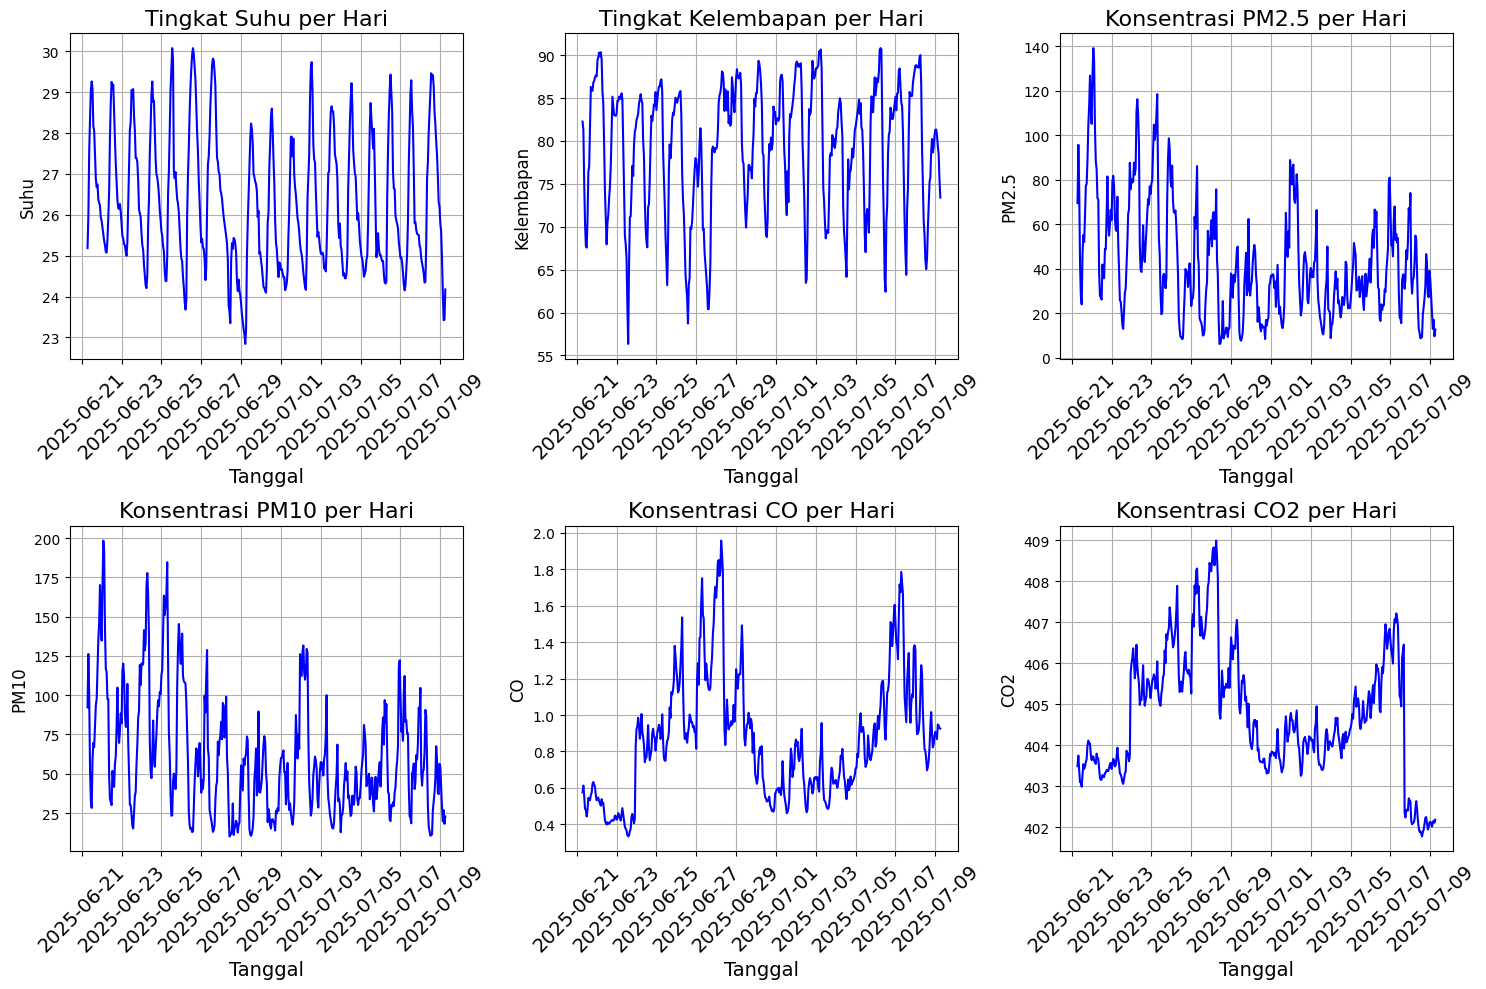

In [9]:
plt.figure(figsize=(15, 10))
plt.subplot(231)
sns.lineplot(data=df_resampled, x='created_at', y='Temperature', color='blue', markers='o')
plt.title('Tingkat Suhu per Hari', fontsize=16)
plt.xlabel('Tanggal', fontsize=14)
plt.ylabel('Suhu', fontsize=12)
plt.xticks(rotation=45, fontsize=14)
plt.grid(True)

plt.subplot(232)
sns.lineplot(data=df_resampled, x='created_at', y='Humidity', color='blue', markers='o')
plt.title('Tingkat Kelembapan per Hari', fontsize=16)
plt.xlabel('Tanggal', fontsize=14)
plt.ylabel('Kelembapan', fontsize=12)
plt.xticks(rotation=45, fontsize=14)
plt.grid(True)

plt.subplot(233)
sns.lineplot(data=df_resampled, x='created_at', y='PM2.5', color='blue', markers='o')
plt.title('Konsentrasi PM2.5 per Hari', fontsize=16)
plt.xlabel('Tanggal', fontsize=14)
plt.ylabel('PM2.5', fontsize=12)
plt.xticks(rotation=45, fontsize=14)
plt.grid(True)

plt.subplot(234)
sns.lineplot(data=df_resampled, x='created_at', y='PM10', color='blue', markers='o')
plt.title('Konsentrasi PM10 per Hari', fontsize=16)
plt.xlabel('Tanggal', fontsize=14)
plt.ylabel('PM10', fontsize=12)
plt.xticks(rotation=45, fontsize=14)
plt.grid(True)

plt.subplot(235)
sns.lineplot(data=df_resampled, x='created_at', y='CO', color='blue', markers='o')
plt.title('Konsentrasi CO per Hari', fontsize=16)
plt.xlabel('Tanggal', fontsize=14)
plt.ylabel('CO', fontsize=12)
plt.xticks(rotation=45, fontsize=14)
plt.grid(True)

plt.subplot(236)
sns.lineplot(data=df_resampled, x='created_at', y='CO2', color='blue', markers='o')
plt.title('Konsentrasi CO2 per Hari', fontsize=16)
plt.xlabel('Tanggal', fontsize=14)
plt.ylabel('CO2', fontsize=12)
plt.xticks(rotation=45, fontsize=14)
plt.grid(True)

plt.tight_layout()
plt.show()

In [10]:
# 1. Split Data
# Tentukan proporsi
n = len(df_resampled)
train_size = int(n * 0.8)
val_size = int(n * 0.1)

# Split berdasarkan urutan waktu
train_df = df_resampled.iloc[:train_size]
val_df   = df_resampled.iloc[train_size:train_size + val_size]
test_df  = df_resampled.iloc[train_size + val_size:]

In [14]:
def scale_co_co2_only(df):
    selected_cols = ['CO', 'CO2']
    scalers = []
    scaled_data = []

    for col in selected_cols:
        scaler = StandardScaler()
        scaled_col = scaler.fit_transform(df[[col]])  # tetap 2D
        scaled_data.append(scaled_col)
        scalers.append(scaler)

    scaled_array = np.hstack(scaled_data)
    return scaled_array, scalers


In [15]:
# Ambil hanya CO dan CO2
train_df_co = train_df[['CO', 'CO2']]
val_df_co = val_df[['CO', 'CO2']]
test_df_co = test_df[['CO', 'CO2']]

# Scaling
train_scaled, scalers = scale_co_co2_only(train_df_co)
val_scaled = np.hstack([scalers[i].transform(val_df_co[[col]]) for i, col in enumerate(val_df_co.columns)])
test_scaled = np.hstack([scalers[i].transform(test_df_co[[col]]) for i, col in enumerate(test_df_co.columns)])


In [30]:
def split_inputs_targets_co_co2(series_batch, ahead=1):
    """
    Input: (batch, seq_length + ahead, 2)
    Output: X: (batch, seq_length, 2), Y: (batch, 2)
    """
    X = series_batch[:, :-ahead, :]        # (batch, seq_length, 2)
    Y = series_batch[:, -ahead, :]         # (batch, 2)
    return X, Y

In [31]:
seq_length = 24
ahead = 1

# Training
ahead_train_ds = tf.keras.utils.timeseries_dataset_from_array(
    data=train_scaled,
    targets=None,
    sequence_length=seq_length + ahead,
    sequence_stride=1,
    shuffle=True,
    batch_size=32
).map(lambda x: split_inputs_targets_co_co2(x, ahead=ahead))

# Validation
ahead_valid_ds = tf.keras.utils.timeseries_dataset_from_array(
    data=val_scaled,
    targets=None,
    sequence_length=seq_length + ahead,
    sequence_stride=1,
    shuffle=True,
    batch_size=32
).map(lambda x: split_inputs_targets_co_co2(x, ahead=ahead))

# Testing
ahead_test_ds = tf.keras.utils.timeseries_dataset_from_array(
    data=test_scaled,
    targets=None,
    sequence_length=seq_length + ahead,
    sequence_stride=1,
    shuffle=False,
    batch_size=32
).map(lambda x: split_inputs_targets_co_co2(x, ahead=ahead))


In [44]:
tf.random.set_seed(42)
tf.keras.backend.clear_session()

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

model_co_co2 = Sequential([
    tf.keras.layers.Input(shape=(24, 2)),
    tf.keras.layers.GRU(256, return_sequences=True),
    tf.keras.layers.GRU(256, return_sequences=True),
    tf.keras.layers.GRU(256, return_sequences=True),
    tf.keras.layers.GRU(256, return_sequences=True),
    tf.keras.layers.GRU(256, return_sequences=True),
    tf.keras.layers.GRU(256, return_sequences=True),
    tf.keras.layers.GRU(256, return_sequences=True),
    tf.keras.layers.GRU(256),
    tf.keras.layers.Dense(32, activation='relu'),
    tf.keras.layers.Dense(2)  # Output: [CO, CO2]
])

model_co_co2.compile(
    optimizer='adam',
    loss='mae',
    metrics=['mae']
)

model_co_co2.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 gru (GRU)                   (None, 24, 256)           199680    
                                                                 
 gru_1 (GRU)                 (None, 24, 256)           394752    
                                                                 
 gru_2 (GRU)                 (None, 24, 256)           394752    
                                                                 
 gru_3 (GRU)                 (None, 24, 256)           394752    
                                                                 
 gru_4 (GRU)                 (None, 24, 256)           394752    
                                                                 
 gru_5 (GRU)                 (None, 24, 256)           394752    
                                                                 
 gru_6 (GRU)                 (None, 24, 256)           3

In [45]:
early_stop = tf.keras.callbacks.EarlyStopping(patience=10, restore_best_weights=True)

model_co_co2.fit(
    ahead_train_ds,
    validation_data=ahead_valid_ds,
    epochs=50,
    callbacks=[early_stop],
    verbose='auto'
)

Epoch 1/50


11/11 [==============================] - 8s 173ms/step - loss: 0.6079 - mae: 0.6079 - val_loss: 1.0877 - val_mae: 1.0877
Epoch 2/50
11/11 [==============================] - 0s 26ms/step - loss: 0.5125 - mae: 0.5125 - val_loss: 0.9609 - val_mae: 0.9609
Epoch 3/50
11/11 [==============================] - 0s 26ms/step - loss: 0.4664 - mae: 0.4664 - val_loss: 0.5993 - val_mae: 0.5993
Epoch 4/50
11/11 [==============================] - 0s 26ms/step - loss: 0.4925 - mae: 0.4925 - val_loss: 0.8371 - val_mae: 0.8371
Epoch 5/50
11/11 [==============================] - 0s 27ms/step - loss: 0.3590 - mae: 0.3590 - val_loss: 0.6276 - val_mae: 0.6276
Epoch 6/50
11/11 [==============================] - 0s 25ms/step - loss: 0.4374 - mae: 0.4374 - val_loss: 0.5357 - val_mae: 0.5357
Epoch 7/50
11/11 [==============================] - 0s 25ms/step - loss: 0.3351 - mae: 0.3351 - val_loss: 0.8273 - val_mae: 0.8273
Epoch 8/50
11/11 [==============================] - 0s 28ms/step - loss: 0.3372 - mae: 0.3372

In [46]:
model_co_co2.evaluate(ahead_test_ds)

1/1 [==============================] - 0s 44ms/step - loss: 1.2899 - mae: 1.2899


[1.2898670434951782, 1.2898670434951782]

In [47]:
def plot_predictions(model, ds_test, scalers, title_suffix=''):
    # Prediksi model
    y_pred_scaled = model.predict(ds_test)

    # Ambil ground truth
    y_true_list = []
    for _, Y_batch in ds_test:
        y_true_list.append(Y_batch.numpy())
    y_true_scaled = np.concatenate(y_true_list, axis=0)  # shape (batch, 2)

    # Inverse transform
    scaler_co = scalers[0]
    scaler_co2 = scalers[1]

    y_pred_co = scaler_co.inverse_transform(y_pred_scaled[:, 0].reshape(-1, 1)).flatten()
    y_true_co = scaler_co.inverse_transform(y_true_scaled[:, 0].reshape(-1, 1)).flatten()

    y_pred_co2 = scaler_co2.inverse_transform(y_pred_scaled[:, 1].reshape(-1, 1)).flatten()
    y_true_co2 = scaler_co2.inverse_transform(y_true_scaled[:, 1].reshape(-1, 1)).flatten()

    # Plot
    plt.figure(figsize=(14, 6))

    # CO
    plt.subplot(1, 2, 1)
    plt.plot(y_true_co, label='Aktual CO', color='blue')
    plt.plot(y_pred_co, label='Prediksi CO', color='orange', linestyle='--')
    plt.title(f'Prediksi vs Aktual CO {title_suffix}')
    plt.xlabel('Waktu (index)')
    plt.ylabel('CO (ppm)')
    plt.legend()

    # CO₂
    plt.subplot(1, 2, 2)
    plt.plot(y_true_co2, label='Aktual CO₂', color='green')
    plt.plot(y_pred_co2, label='Prediksi CO₂', color='red', linestyle='--')
    plt.title(f'Prediksi vs Aktual CO₂ {title_suffix}')
    plt.xlabel('Waktu (index)')
    plt.ylabel('CO₂ (ppm)')
    plt.legend()

    plt.tight_layout()
    plt.show()


1/1 [==============================] - 1s 1s/step


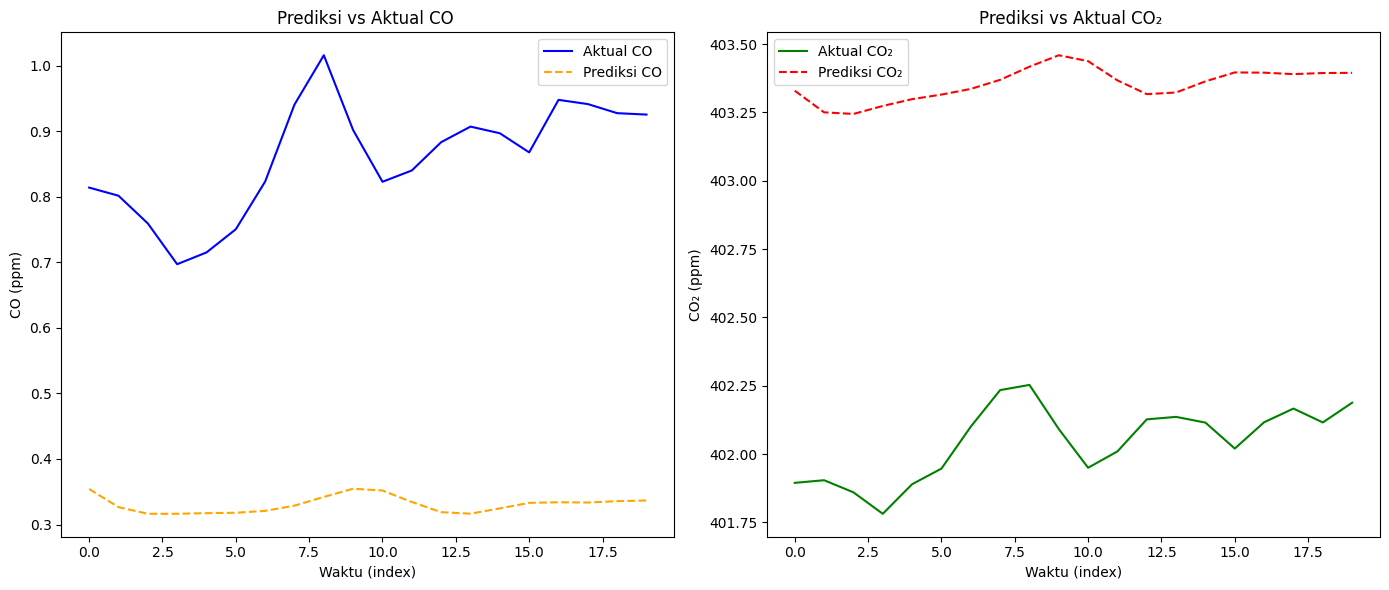

In [48]:
plot_predictions(model_co_co2, ahead_test_ds, scalers)

In [49]:
# === 1. Load & Split Data ===
df = df_resampled[['CO']]  # atau ['CO2'] jika ingin target CO2
train_size = int(len(df) * 0.8)
val_size = int(len(df) * 0.1)

train_df = df.iloc[:train_size]
val_df = df.iloc[train_size:train_size + val_size]
test_df = df.iloc[train_size + val_size:]

# === 2. Scaling ===
scaler = MinMaxScaler()
train_scaled = scaler.fit_transform(train_df)
val_scaled = scaler.transform(val_df)
test_scaled = scaler.transform(test_df)

# === 3. Windowing ===
seq_length = 24
ahead = 1

def create_dataset(series, seq_length=24, ahead=1, shuffle=True):
    ds = tf.keras.utils.timeseries_dataset_from_array(
        data=series,
        targets=None,
        sequence_length=seq_length + ahead,
        sequence_stride=1,
        shuffle=shuffle,
        batch_size=32
    )
    return ds.map(lambda x: (x[:, :-ahead], x[:, -ahead:, :]))

train_ds = create_dataset(train_scaled, seq_length, ahead)
val_ds = create_dataset(val_scaled, seq_length, ahead)
test_ds = create_dataset(test_scaled, seq_length, ahead, shuffle=False)


In [58]:
# === 4. Model ===
model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(seq_length, 1)),
    tf.keras.layers.LSTM(256, return_sequences=True),
    tf.keras.layers.LSTM(256, return_sequences=True),
    tf.keras.layers.LSTM(256),
    tf.keras.layers.Dense(1)
])

model.compile(optimizer='adam', loss='mae', metrics=['mae'])
model.summary()

Model: "sequential_5"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 lstm_20 (LSTM)              (None, 24, 256)           264192    
                                                                 
 lstm_21 (LSTM)              (None, 24, 256)           525312    
                                                                 
 lstm_22 (LSTM)              (None, 256)               525312    
                                                                 
 dense_6 (Dense)             (None, 1)                 257       
                                                                 
Total params: 1,315,073
Trainable params: 1,315,073
Non-trainable params: 0
_________________________________________________________________


In [59]:
# === 5. Training ===
model.fit(train_ds, validation_data=val_ds, epochs=50)

# === 6. Evaluation ===
model.evaluate(test_ds)

Epoch 1/50


11/11 [==============================] - 3s 88ms/step - loss: 0.1580 - mae: 0.1580 - val_loss: 0.3294 - val_mae: 0.3294
Epoch 2/50
11/11 [==============================] - 0s 14ms/step - loss: 0.1167 - mae: 0.1167 - val_loss: 0.1389 - val_mae: 0.1389
Epoch 3/50
11/11 [==============================] - 0s 13ms/step - loss: 0.1134 - mae: 0.1134 - val_loss: 0.3292 - val_mae: 0.3292
Epoch 4/50
11/11 [==============================] - 0s 13ms/step - loss: 0.1006 - mae: 0.1006 - val_loss: 0.0941 - val_mae: 0.0941
Epoch 5/50
11/11 [==============================] - 0s 15ms/step - loss: 0.1012 - mae: 0.1012 - val_loss: 0.2093 - val_mae: 0.2093
Epoch 6/50
11/11 [==============================] - 0s 14ms/step - loss: 0.0910 - mae: 0.0910 - val_loss: 0.2121 - val_mae: 0.2121
Epoch 7/50
11/11 [==============================] - 0s 13ms/step - loss: 0.0824 - mae: 0.0824 - val_loss: 0.1534 - val_mae: 0.1534
Epoch 8/50
11/11 [==============================] - 0s 13ms/step - loss: 0.0805 - mae: 0.0805 

[0.037487342953681946, 0.037487342953681946]

1/1 [==============================] - 1s 587ms/step


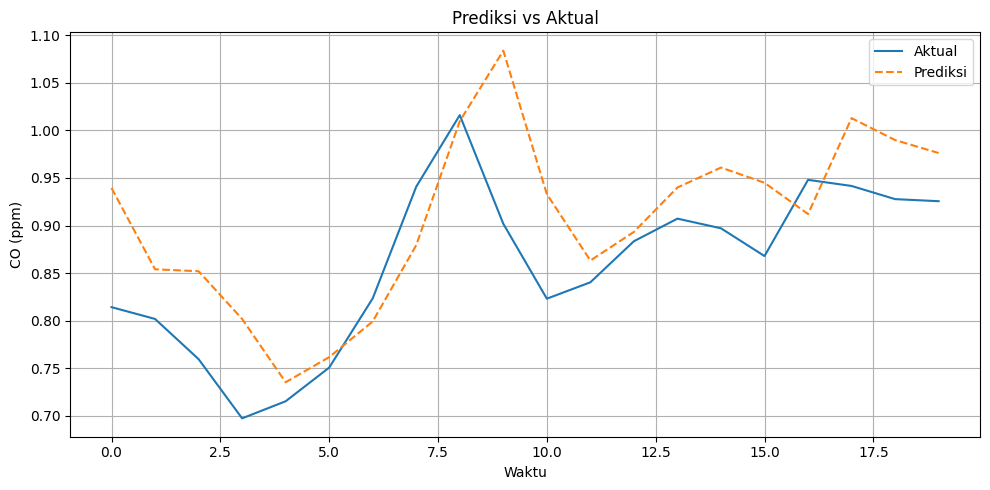

In [60]:
# === 7. Plot Prediction vs Ground Truth ===
y_pred_scaled = model.predict(test_ds)
y_true = np.concatenate([y for x, y in test_ds], axis=0)

# Inverse scaling
y_pred = scaler.inverse_transform(y_pred_scaled)
y_true = scaler.inverse_transform(y_true[:, 0, :])

import matplotlib.pyplot as plt
plt.figure(figsize=(10,5))
plt.plot(y_true, label='Aktual')
plt.plot(y_pred, label='Prediksi', linestyle='--')
plt.legend()
plt.title('Prediksi vs Aktual')
plt.xlabel('Waktu')
plt.ylabel('CO (ppm)')
plt.grid(True)
plt.tight_layout()
plt.show()

In [61]:
# === 1. Load & Split Data ===
df = df_resampled[['CO2']]  # atau ['CO2'] jika ingin target CO2
train_size = int(len(df) * 0.8)
val_size = int(len(df) * 0.1)

train_df = df.iloc[:train_size]
val_df = df.iloc[train_size:train_size + val_size]
test_df = df.iloc[train_size + val_size:]

# === 2. Scaling ===
scaler = MinMaxScaler()
train_scaled = scaler.fit_transform(train_df)
val_scaled = scaler.transform(val_df)
test_scaled = scaler.transform(test_df)

# === 3. Windowing ===
seq_length = 24
ahead = 1

def create_dataset(series, seq_length=24, ahead=1, shuffle=True):
    ds = tf.keras.utils.timeseries_dataset_from_array(
        data=series,
        targets=None,
        sequence_length=seq_length + ahead,
        sequence_stride=1,
        shuffle=shuffle,
        batch_size=32
    )
    return ds.map(lambda x: (x[:, :-ahead], x[:, -ahead:, :]))

train_ds = create_dataset(train_scaled, seq_length, ahead)
val_ds = create_dataset(val_scaled, seq_length, ahead)
test_ds = create_dataset(test_scaled, seq_length, ahead, shuffle=False)

In [62]:
# === 4. Model ===
model_co2 = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(seq_length, 1)),
    tf.keras.layers.LSTM(256, return_sequences=True),
    tf.keras.layers.LSTM(256, return_sequences=True),
    tf.keras.layers.LSTM(256),
    tf.keras.layers.Dense(1)
])

model_co2.compile(optimizer='adam', loss='mae', metrics=['mae'])
model_co2.summary()

Model: "sequential_6"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 lstm_23 (LSTM)              (None, 24, 256)           264192    
                                                                 
 lstm_24 (LSTM)              (None, 24, 256)           525312    
                                                                 
 lstm_25 (LSTM)              (None, 256)               525312    
                                                                 
 dense_7 (Dense)             (None, 1)                 257       
                                                                 
Total params: 1,315,073
Trainable params: 1,315,073
Non-trainable params: 0
_________________________________________________________________


In [64]:
# === 5. Training ===
model_co2.fit(train_ds, validation_data=val_ds, epochs=50)

# === 6. Evaluation ===
model_co2.evaluate(test_ds)

Epoch 1/50


11/11 [==============================] - 3s 91ms/step - loss: 0.1550 - mae: 0.1550 - val_loss: 0.2735 - val_mae: 0.2735
Epoch 2/50
11/11 [==============================] - 0s 19ms/step - loss: 0.1496 - mae: 0.1496 - val_loss: 0.1175 - val_mae: 0.1175
Epoch 3/50
11/11 [==============================] - 0s 13ms/step - loss: 0.1265 - mae: 0.1265 - val_loss: 0.1427 - val_mae: 0.1427
Epoch 4/50
11/11 [==============================] - 0s 15ms/step - loss: 0.1038 - mae: 0.1038 - val_loss: 0.1061 - val_mae: 0.1061
Epoch 5/50
11/11 [==============================] - 0s 15ms/step - loss: 0.0930 - mae: 0.0930 - val_loss: 0.1097 - val_mae: 0.1097
Epoch 6/50
11/11 [==============================] - 0s 15ms/step - loss: 0.0862 - mae: 0.0862 - val_loss: 0.1304 - val_mae: 0.1304
Epoch 7/50
11/11 [==============================] - 0s 13ms/step - loss: 0.0904 - mae: 0.0904 - val_loss: 0.0738 - val_mae: 0.0738
Epoch 8/50
11/11 [==============================] - 0s 15ms/step - loss: 0.0790 - mae: 0.0790 

[0.015734266489744186, 0.015734266489744186]

1/1 [==============================] - 0s 41ms/step


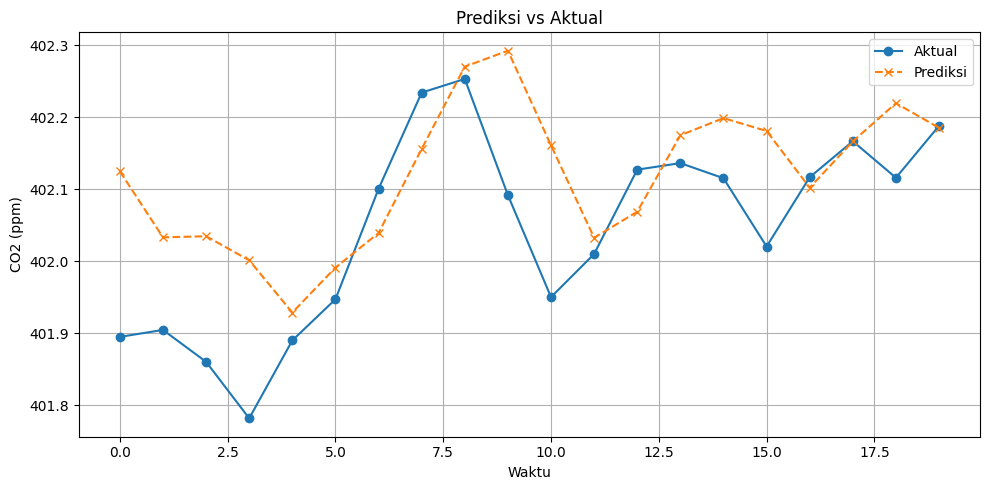

In [66]:
# === 7. Plot Prediction vs Ground Truth ===
y_pred_scaled = model_co2.predict(test_ds)
y_true = np.concatenate([y for x, y in test_ds], axis=0)

# Inverse scaling
y_pred = scaler.inverse_transform(y_pred_scaled)
y_true = scaler.inverse_transform(y_true[:, 0, :])

import matplotlib.pyplot as plt
plt.figure(figsize=(10,5))
plt.plot(y_true, label='Aktual', marker='o')
plt.plot(y_pred, label='Prediksi', linestyle='--', marker='x')
plt.legend()
plt.title('Prediksi vs Aktual')
plt.xlabel('Waktu')
plt.ylabel('CO2 (ppm)')
plt.grid(True)
plt.tight_layout()
plt.show()

## Model Gabungan 

In [72]:
# === 2. Split Data ===
n = len(df_resampled)
train_size = int(n * 0.8)
val_size = int(n * 0.1)

In [73]:
# Scaling ulang hanya untuk kolom CO dan CO2
train_df = df_resampled.iloc[:train_size][['CO', 'CO2']]
val_df   = df_resampled.iloc[train_size:train_size + val_size][['CO', 'CO2']]
test_df  = df_resampled.iloc[train_size + val_size:][['CO', 'CO2']]

scalers = []
train_scaled, val_scaled, test_scaled = [], [], []

for col in ['CO', 'CO2']:
    scaler = StandardScaler()
    train_scaled.append(scaler.fit_transform(train_df[[col]]))
    val_scaled.append(scaler.transform(val_df[[col]]))
    test_scaled.append(scaler.transform(test_df[[col]]))
    scalers.append(scaler)

train_scaled = np.hstack(train_scaled)
val_scaled   = np.hstack(val_scaled)
test_scaled  = np.hstack(test_scaled)

In [78]:
seq_length = 24
ahead = 1

def split_input_target(batch, ahead=1):
    X = batch[:, :-ahead, :]            # (batch, 24, 2)
    Y = batch[:, -ahead:, :]            # (batch, 1, 2)
    Y = tf.squeeze(Y, axis=1)           # → (batch, 2)
    return X, Y

def make_dataset(data, shuffle=True):
    ds = tf.keras.utils.timeseries_dataset_from_array(
        data=data,
        targets=None,
        sequence_length=seq_length + ahead,
        sequence_stride=1,
        shuffle=shuffle,
        batch_size=32
    )
    return ds.map(lambda x: split_input_target(x, ahead))

# Datasets
ds_train = make_dataset(train_scaled, shuffle=True)
ds_val   = make_dataset(val_scaled, shuffle=True)
ds_test  = make_dataset(test_scaled, shuffle=False)


In [88]:
# === 5. Model Multi-Output ===
model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(seq_length, 2)),
    tf.keras.layers.LSTM(128, return_sequences=True),
    tf.keras.layers.LSTM(128),
    tf.keras.layers.Dense(32, activation="relu"),
    tf.keras.layers.Dense(2)  # output: CO dan CO₂
])

model.compile(optimizer="adam", loss="mae", metrics=["mae"])
model.summary()

Model: "sequential_10"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 lstm_34 (LSTM)              (None, 24, 128)           67072     
                                                                 
 lstm_35 (LSTM)              (None, 128)               131584    
                                                                 
 dense_16 (Dense)            (None, 32)                4128      
                                                                 
 dense_17 (Dense)            (None, 2)                 66        
                                                                 
Total params: 202,850
Trainable params: 202,850
Non-trainable params: 0
_________________________________________________________________


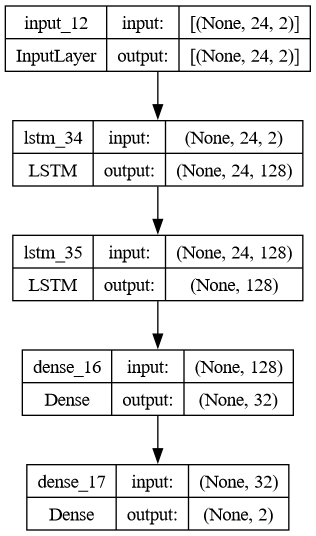

In [89]:
tf.keras.utils.plot_model(model, show_shapes=True)

In [90]:
# === 6. Train ===
history = model.fit(ds_train, validation_data=ds_val, epochs=50)

# === 7. Evaluate ===
model.evaluate(ds_test)

Epoch 1/50
11/11 [==============================] - 3s 65ms/step - loss: 0.5677 - mae: 0.5677 - val_loss: 0.9254 - val_mae: 0.9254
Epoch 2/50
11/11 [==============================] - 0s 18ms/step - loss: 0.4709 - mae: 0.4709 - val_loss: 0.6862 - val_mae: 0.6862
Epoch 3/50
11/11 [==============================] - 0s 15ms/step - loss: 0.4137 - mae: 0.4137 - val_loss: 0.9788 - val_mae: 0.9788
Epoch 4/50
11/11 [==============================] - 0s 14ms/step - loss: 0.3926 - mae: 0.3926 - val_loss: 0.7008 - val_mae: 0.7008
Epoch 5/50
11/11 [==============================] - 0s 15ms/step - loss: 0.3468 - mae: 0.3468 - val_loss: 0.8027 - val_mae: 0.8027
Epoch 6/50
11/11 [==============================] - 0s 16ms/step - loss: 0.3249 - mae: 0.3249 - val_loss: 0.5998 - val_mae: 0.5998
Epoch 7/50
11/11 [==============================] - 0s 15ms/step - loss: 0.3567 - mae: 0.3567 - val_loss: 0.9058 - val_mae: 0.9058
Epoch 8/50
11/11 [==============================] - 0s 14ms/step - loss: 0.3429 - m

[0.667454183101654, 0.667454183101654]

1/1 [==============================] - 1s 519ms/step


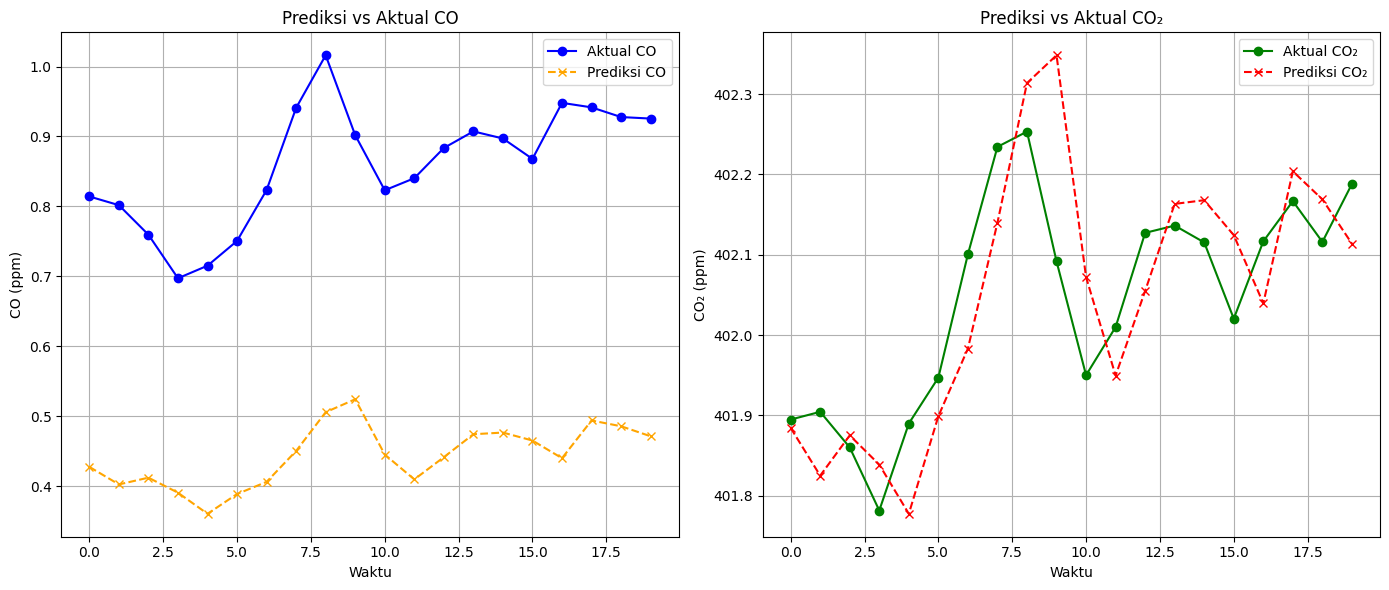

In [91]:
# === 8. Visualisasi Prediksi vs Aktual ===
y_pred_scaled = model.predict(ds_test)
y_true_scaled = np.concatenate([y for _, y in ds_test], axis=0)

# Inverse transform
y_pred_co   = scalers[0].inverse_transform(y_pred_scaled[:, 0].reshape(-1, 1)).flatten()
y_true_co   = scalers[0].inverse_transform(y_true_scaled[:, 0].reshape(-1, 1)).flatten()
y_pred_co2  = scalers[1].inverse_transform(y_pred_scaled[:, 1].reshape(-1, 1)).flatten()
y_true_co2  = scalers[1].inverse_transform(y_true_scaled[:, 1].reshape(-1, 1)).flatten()

# Plot
plt.figure(figsize=(14, 6))

# CO plot
plt.subplot(1, 2, 1)
plt.plot(y_true_co[:20], label='Aktual CO', color='blue', marker='o')
plt.plot(y_pred_co[:20], label='Prediksi CO', color='orange', linestyle='--', marker='x')
plt.title("Prediksi vs Aktual CO")
plt.xlabel("Waktu")
plt.ylabel("CO (ppm)")
plt.legend()
plt.grid()

# CO₂ plot
plt.subplot(1, 2, 2)
plt.plot(y_true_co2[:20], label='Aktual CO₂', color='green', marker='o')
plt.plot(y_pred_co2[:20], label='Prediksi CO₂', color='red', linestyle='--', marker='x')
plt.title("Prediksi vs Aktual CO₂")
plt.xlabel("Waktu")
plt.ylabel("CO₂ (ppm)")
plt.legend()
plt.grid()

plt.tight_layout()
plt.show()

In [92]:
# --- Gunakan data df_resampled kamu ---
df = df_resampled[['CO', 'CO2']].dropna()

# --- Split data ---
n = len(df)
train_size = int(n * 0.8)
val_size = int(n * 0.1)

train_df = df.iloc[:train_size]
val_df = df.iloc[train_size:train_size + val_size]
test_df = df.iloc[train_size + val_size:]

# --- Scaling ---
scaler_co = MinMaxScaler()
scaler_co2 = MinMaxScaler()

train_scaled = np.hstack([
    scaler_co.fit_transform(train_df[['CO']]),
    scaler_co2.fit_transform(train_df[['CO2']])
])

val_scaled = np.hstack([
    scaler_co.transform(val_df[['CO']]),
    scaler_co2.transform(val_df[['CO2']])
])

test_scaled = np.hstack([
    scaler_co.transform(test_df[['CO']]),
    scaler_co2.transform(test_df[['CO2']])
])

In [93]:
seq_length = 24
ahead = 1

def make_dataset(data, shuffle=True):
    ds = tf.keras.utils.timeseries_dataset_from_array(
        data=data,
        targets=None,
        sequence_length=seq_length + ahead,
        sequence_stride=1,
        shuffle=shuffle,
        batch_size=32
    )

    def split_fn(batch):
        x = batch[:, :-ahead, :]
        y = batch[:, -ahead:, :]
        return x, {
            'CO': y[:, 0, 0:1],   # CO target
            'CO2': y[:, 0, 1:2]   # CO2 target
        }

    return ds.map(split_fn)

ds_train = make_dataset(train_scaled)
ds_val = make_dataset(val_scaled)
ds_test = make_dataset(test_scaled, shuffle=False)


In [94]:
from tensorflow.keras.layers import Input, LSTM, Dense
from tensorflow.keras.models import Model

inputs = Input(shape=(seq_length, 2))
x = LSTM(128, return_sequences=True)(inputs)
x = LSTM(64)(x)

# CO branch
co_branch = Dense(32, activation='relu')(x)
co_output = Dense(1, name='CO')(co_branch)

# CO2 branch
co2_branch = Dense(32, activation='relu')(x)
co2_output = Dense(1, name='CO2')(co2_branch)

model = Model(inputs=inputs, outputs=[co_output, co2_output])
model.compile(optimizer='adam', loss='mae', metrics=['mae'])

model.summary()


Model: "model_1"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_13 (InputLayer)          [(None, 24, 2)]      0           []                               
                                                                                                  
 lstm_36 (LSTM)                 (None, 24, 128)      67072       ['input_13[0][0]']               
                                                                                                  
 lstm_37 (LSTM)                 (None, 64)           49408       ['lstm_36[0][0]']                
                                                                                                  
 dense_18 (Dense)               (None, 32)           2080        ['lstm_37[0][0]']                
                                                                                            

In [95]:
history = model.fit(ds_train, validation_data=ds_val, epochs=50)
model.evaluate(ds_test)

Epoch 1/50
11/11 [==============================] - 3s 63ms/step - loss: 0.3709 - CO_loss: 0.1667 - CO2_loss: 0.2042 - CO_mae: 0.1667 - CO2_mae: 0.2042 - val_loss: 0.4783 - val_CO_loss: 0.3523 - val_CO2_loss: 0.1260 - val_CO_mae: 0.3523 - val_CO2_mae: 0.1260
Epoch 2/50
11/11 [==============================] - 0s 17ms/step - loss: 0.2476 - CO_loss: 0.1117 - CO2_loss: 0.1359 - CO_mae: 0.1117 - CO2_mae: 0.1359 - val_loss: 0.2691 - val_CO_loss: 0.1564 - val_CO2_loss: 0.1127 - val_CO_mae: 0.1564 - val_CO2_mae: 0.1127
Epoch 3/50
11/11 [==============================] - 0s 15ms/step - loss: 0.1981 - CO_loss: 0.0915 - CO2_loss: 0.1067 - CO_mae: 0.0915 - CO2_mae: 0.1067 - val_loss: 0.4823 - val_CO_loss: 0.3315 - val_CO2_loss: 0.1508 - val_CO_mae: 0.3315 - val_CO2_mae: 0.1508
Epoch 4/50
11/11 [==============================] - 0s 15ms/step - loss: 0.1915 - CO_loss: 0.0891 - CO2_loss: 0.1023 - CO_mae: 0.0891 - CO2_mae: 0.1023 - val_loss: 0.3727 - val_CO_loss: 0.2480 - val_CO2_loss: 0.1247 - val_C

[0.09100441634654999,
 0.04537995159626007,
 0.045624468475580215,
 0.04537995159626007,
 0.045624468475580215]

1/1 [==============================] - 0s 427ms/step


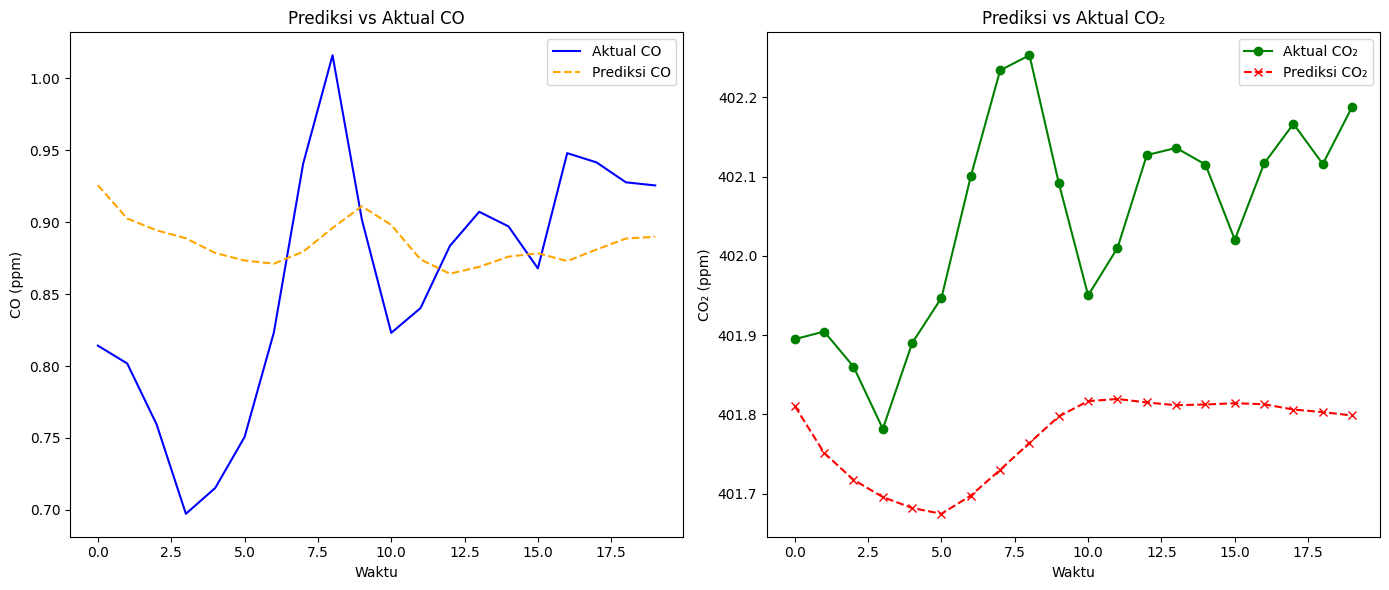

In [96]:
y_pred_co, y_pred_co2 = model.predict(ds_test)

y_true_co, y_true_co2 = [], []
for _, y in ds_test:
    y_true_co.append(y['CO'].numpy())
    y_true_co2.append(y['CO2'].numpy())

y_true_co = np.concatenate(y_true_co).reshape(-1, 1)
y_true_co2 = np.concatenate(y_true_co2).reshape(-1, 1)

# Inverse transform
y_pred_co_inv = scaler_co.inverse_transform(y_pred_co).flatten()
y_true_co_inv = scaler_co.inverse_transform(y_true_co).flatten()

y_pred_co2_inv = scaler_co2.inverse_transform(y_pred_co2).flatten()
y_true_co2_inv = scaler_co2.inverse_transform(y_true_co2).flatten()

# Plot
plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
plt.plot(y_true_co_inv[:20], label='Aktual CO', color='blue')
plt.plot(y_pred_co_inv[:20], label='Prediksi CO', color='orange', linestyle='--')
plt.title("Prediksi vs Aktual CO")
plt.xlabel("Waktu")
plt.ylabel("CO (ppm)")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(y_true_co2_inv[:20], label='Aktual CO₂', color='green', marker='o')
plt.plot(y_pred_co2_inv[:20], label='Prediksi CO₂', color='red', linestyle='--', marker='x')
plt.title("Prediksi vs Aktual CO₂")
plt.xlabel("Waktu")
plt.ylabel("CO₂ (ppm)")
plt.legend()

plt.tight_layout()
plt.show()


## Full 4 fitur

In [104]:
n = len(df_resampled)
train_size = int(n * 0.8)
val_size = int(n * 0.1)

train_df = df_resampled.iloc[:train_size]
val_df = df_resampled.iloc[train_size:train_size + val_size]
test_df = df_resampled.iloc[train_size + val_size:]

feature_names = ["PM2.5", "PM10", "CO", "CO2"]
scalers = []

def scale_data(df):
    scaled = []
    for col in feature_names:
        scaler = StandardScaler()
        scaled.append(scaler.fit_transform(df[[col]]))
        scalers.append(scaler)
    return np.hstack(scaled)

train_scaled = scale_data(train_df)
val_scaled = np.hstack([scalers[i].transform(val_df[[col]]) for i, col in enumerate(feature_names)])
test_scaled = np.hstack([scalers[i].transform(test_df[[col]]) for i, col in enumerate(feature_names)])


In [105]:
sequence_length = 24
forecast_horizon = 1

def split_seq2vec(batch):
    x = batch[:, :-forecast_horizon, :]
    y = batch[:, -forecast_horizon, :]
    return x, y

def make_dataset(data, shuffle=True):
    ds = tf.keras.utils.timeseries_dataset_from_array(
        data=data,
        targets=None,
        sequence_length=sequence_length + forecast_horizon,
        sequence_stride=1,
        shuffle=shuffle,
        batch_size=32
    )
    return ds.map(split_seq2vec)

ds_train = make_dataset(train_scaled)
ds_val   = make_dataset(val_scaled)
ds_test  = make_dataset(test_scaled, shuffle=False)


In [130]:
import os
def create_model_checkpoint(model_name, save_path="model_experiments_V4"):
  return tf.keras.callbacks.ModelCheckpoint(
    filepath=os.path.join(save_path, model_name), # create filepath to save model
    verbose=0, # only output a limited amount of text
    save_best_only=True) # save only the best model to file

In [131]:
input_layer = Input(shape=(sequence_length, 4))
x = LSTM(512, return_sequences=True)(input_layer)
x = LSTM(256)(x)
output = Dense(4)(x)

model = Model(inputs=input_layer, outputs=output, name='Model_1H_LSTM')
model.compile(optimizer='sgd', loss='huber', metrics=['mae'])
model.summary()


Model: "Model_1H_LSTM"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_22 (InputLayer)       [(None, 24, 4)]           0         
                                                                 
 lstm_55 (LSTM)              (None, 24, 512)           1058816   
                                                                 
 lstm_56 (LSTM)              (None, 256)               787456    
                                                                 
 dense_28 (Dense)            (None, 4)                 1028      
                                                                 
Total params: 1,847,300
Trainable params: 1,847,300
Non-trainable params: 0
_________________________________________________________________


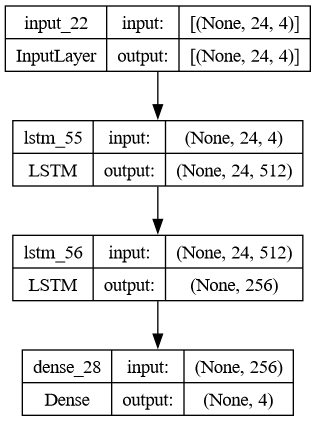

In [132]:
tf.keras.utils.plot_model(model, show_shapes=True)

In [134]:
from tensorflow.keras.callbacks import ReduceLROnPlateau

lr_schedule = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=10,
    min_lr=1e-6
)

In [136]:
with tf.device('/GPU:0'):
    history = model.fit(ds_train, validation_data=ds_val, epochs=500, callbacks=[create_model_checkpoint(model_name=model.name), lr_schedule])
    model.evaluate(ds_test)

Epoch 1/500
 9/11 [=======================>......] - ETA: 0s - loss: 0.2129 - mae: 0.5130

INFO:tensorflow:Assets written to: model_experiments_V4\Model_1H_LSTM\assets


INFO:tensorflow:Assets written to: model_experiments_V4\Model_1H_LSTM\assets


11/11 [==============================] - 4s 419ms/step - loss: 0.2118 - mae: 0.5132 - val_loss: 0.2939 - val_mae: 0.6410 - lr: 0.0100
Epoch 2/500
11/11 [==============================] - 0s 30ms/step - loss: 0.2112 - mae: 0.5123 - val_loss: 0.2973 - val_mae: 0.6459 - lr: 0.0100
Epoch 3/500
11/11 [==============================] - 0s 11ms/step - loss: 0.2104 - mae: 0.5109 - val_loss: 0.2993 - val_mae: 0.6486 - lr: 0.0100
Epoch 4/500
 8/11 [====================>.........] - ETA: 0s - loss: 0.2030 - mae: 0.5038

INFO:tensorflow:Assets written to: model_experiments_V4\Model_1H_LSTM\assets


...

INFO:tensorflow:Assets written to: model_experiments_V4\Model_1H_LSTM\assets


11/11 [==============================] - 5s 484ms/step - loss: 0.2084 - mae: 0.5083 - val_loss: 0.2773 - val_mae: 0.6163 - lr: 0.0100
Epoch 7/500
 8/11 [====================>.........] - ETA: 0s - loss: 0.1968 - mae: 0.4945

INFO:tensorflow:Assets written to: model_experiments_V4\Model_1H_LSTM\assets


INFO:tensorflow:Assets written to: model_experiments_V4\Model_1H_LSTM\assets


11/11 [==============================] - 4s 406ms/step - loss: 0.2085 - mae: 0.5087 - val_loss: 0.2509 - val_mae: 0.5775 - lr: 0.0100
Epoch 8/500
11/11 [==============================] - 0s 33ms/step - loss: 0.2091 - mae: 0.5098 - val_loss: 0.2623 - val_mae: 0.5930 - lr: 0.0100
Epoch 9/500
11/11 [==============================] - 0s 11ms/step - loss: 0.2070 - mae: 0.5065 - val_loss: 0.2685 - val_mae: 0.6018 - lr: 0.0100
Epoch 10/500
11/11 [==============================] - 0s 12ms/step - loss: 0.2058 - mae: 0.5048 - val_loss: 0.2745 - val_mae: 0.6103 - lr: 0.0100
Epoch 11/500
11/11 [==============================] - 0s 11ms/step - loss: 0.2046 - mae: 0.5031 - val_loss: 0.2986 - val_mae: 0.6456 - lr: 0.0100
Epoch 12/500
11/11 [==============================] - 0s 11ms/step - loss: 0.2036 - mae: 0.5018 - val_loss: 0.3162 - val_mae: 0.6699 - lr: 0.0100
Epoch 13/500
11/11 [==============================] - 0s 11ms/step - loss: 0.2032 - mae: 0.5010 - val_loss: 0.2946 - val_mae: 0.6394 - lr:

In [138]:
# Load in saved best performing model_1 and evaluate on test data
model = tf.keras.models.load_model("model_experiments_V4/Model_1H_LSTM")
model.evaluate(ds_test)

1/1 [==============================] - 0s 459ms/step - loss: 0.3597 - mae: 0.7507


[0.3597056269645691, 0.7507401704788208]

1/1 [==============================] - 0s 399ms/step


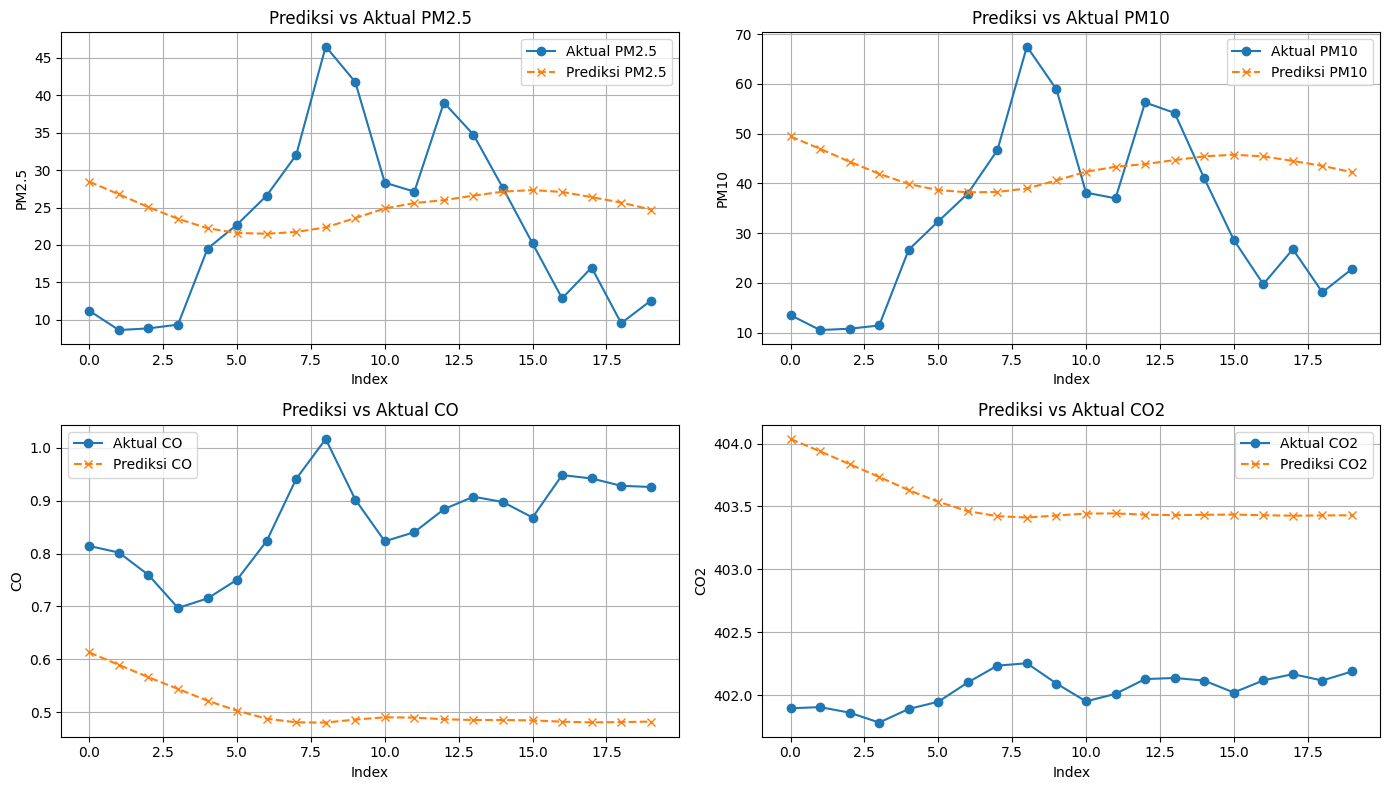

In [139]:
y_pred_scaled = model.predict(ds_test)
y_true_scaled = np.concatenate([y for _, y in ds_test], axis=0)

# Inverse
y_pred_inv, y_true_inv = [], []
for i in range(4):
    y_pred_inv.append(scalers[i].inverse_transform(y_pred_scaled[:, i].reshape(-1, 1)).flatten())
    y_true_inv.append(scalers[i].inverse_transform(y_true_scaled[:, i].reshape(-1, 1)).flatten())

# Plot
plt.figure(figsize=(14, 8))
for i, name in enumerate(feature_names):
    plt.subplot(2, 2, i+1)
    plt.plot(y_true_inv[i][:20], label='Aktual ' + name, marker='o')
    plt.plot(y_pred_inv[i][:20], label='Prediksi ' + name, linestyle='--', marker='x')
    plt.title(f'Prediksi vs Aktual {name}')
    plt.legend()
    plt.xlabel('Index')
    plt.ylabel(name)
    plt.grid()
plt.tight_layout()
plt.show()


In [140]:
# === Split Data ===
n = len(df_resampled)
train_size = int(n * 0.8)
val_size = int(n * 0.1)

train_df = df_resampled.iloc[:train_size]
val_df   = df_resampled.iloc[train_size:train_size + val_size]
test_df  = df_resampled.iloc[train_size + val_size:]

# === Scaling per fitur ===
scalers = {}
train_scaled = []
val_scaled = []
test_scaled = []

for col in ['PM2.5', 'PM10', 'CO', 'CO2']:
    scaler = StandardScaler()
    train_scaled.append(scaler.fit_transform(train_df[[col]]))
    val_scaled.append(scaler.transform(val_df[[col]]))
    test_scaled.append(scaler.transform(test_df[[col]]))
    scalers[col] = scaler

train_scaled = np.hstack(train_scaled)
val_scaled = np.hstack(val_scaled)
test_scaled = np.hstack(test_scaled)

In [146]:
sequence_length = 36
ahead = 1

def split_input_target(batch):
    X = batch[:, :-ahead, :]
    Y = batch[:, -ahead, :]
    return X, Y

def make_dataset(data, shuffle=True):
    ds = tf.keras.utils.timeseries_dataset_from_array(
        data=data,
        targets=None,
        sequence_length=sequence_length + ahead,
        sequence_stride=1,
        shuffle=shuffle,
        batch_size=32
    )
    return ds.map(split_input_target)

ds_train = make_dataset(train_scaled)
ds_val   = make_dataset(val_scaled)
ds_test  = make_dataset(test_scaled, shuffle=False)


In [156]:
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Conv1D, MaxPooling1D, LSTM, Dense, Dropout, LayerNormalization

# === Konfigurasi
sequence_length = 36
num_features = 4  # PM2.5, PM10, CO, CO2

# === Arsitektur Hybrid CNN + LSTM
inputs = Input(shape=(sequence_length, num_features), name='input_layer')

# CNN block
x = Conv1D(filters=64, kernel_size=3, padding='same', activation='relu')(inputs)
x = MaxPooling1D(pool_size=2)(x)
x = Conv1D(filters=128, kernel_size=3, padding='same', activation='relu')(x)
x = MaxPooling1D(pool_size=2)(x)
x = LayerNormalization()(x)  # Normalisasi untuk stabilisasi

# LSTM block
x = LSTM(128, return_sequences=True)(x)
x = Dropout(0.2)(x)
x = LSTM(64)(x)
x = Dropout(0.2)(x)

# Dense layers
x = Dense(64, activation='relu')(x)
x = Dropout(0.2)(x)
outputs = Dense(num_features)(x)  # 4 output

model = Model(inputs, outputs, name='Hybrid_CNN_LSTM')

# === Kompilasi
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
              loss='mae',
              metrics=['mae'])

model.summary()



Model: "Hybrid_CNN_LSTM"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_layer (InputLayer)    [(None, 36, 4)]           0         
                                                                 
 conv1d_2 (Conv1D)           (None, 36, 64)            832       
                                                                 
 max_pooling1d_2 (MaxPooling  (None, 18, 64)           0         
 1D)                                                             
                                                                 
 conv1d_3 (Conv1D)           (None, 18, 128)           24704     
                                                                 
 max_pooling1d_3 (MaxPooling  (None, 9, 128)           0         
 1D)                                                             
                                                                 
 layer_normalization (LayerN  (None, 9, 128)       

In [157]:
# === Training
history = model.fit(ds_train, validation_data=ds_val, epochs=100)

# === Evaluasi
model.evaluate(ds_test)


Epoch 1/100


10/10 [==============================] - 2s 64ms/step - loss: 0.6811 - mae: 0.6811 - val_loss: 1.1553 - val_mae: 1.1553
Epoch 2/100
10/10 [==============================] - 0s 14ms/step - loss: 0.5719 - mae: 0.5719 - val_loss: 0.8922 - val_mae: 0.8922
Epoch 3/100
10/10 [==============================] - 0s 13ms/step - loss: 0.5628 - mae: 0.5628 - val_loss: 0.7040 - val_mae: 0.7040
Epoch 4/100
10/10 [==============================] - 0s 14ms/step - loss: 0.5245 - mae: 0.5245 - val_loss: 1.0614 - val_mae: 1.0614
Epoch 5/100
10/10 [==============================] - 0s 13ms/step - loss: 0.5242 - mae: 0.5242 - val_loss: 0.6135 - val_mae: 0.6135
Epoch 6/100
10/10 [==============================] - 0s 13ms/step - loss: 0.4897 - mae: 0.4897 - val_loss: 0.7456 - val_mae: 0.7456
Epoch 7/100
10/10 [==============================] - 0s 13ms/step - loss: 0.4569 - mae: 0.4569 - val_loss: 0.8070 - val_mae: 0.8070
Epoch 8/100
10/10 [==============================] - 0s 12ms/step - loss: 0.4260 - mae: 

[0.6843831539154053, 0.6843831539154053]

1/1 [==============================] - 0s 448ms/step


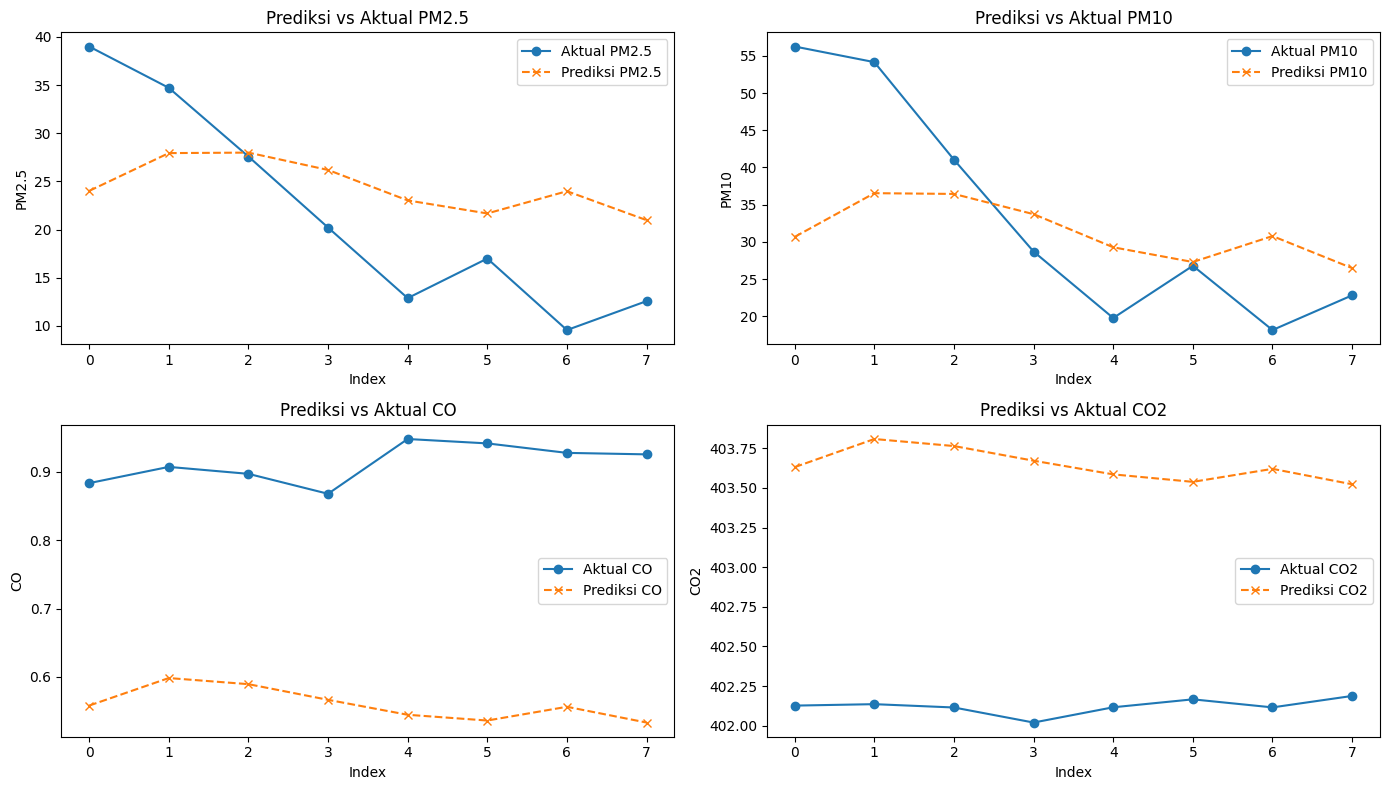

In [158]:
# Prediksi dan Ground Truth
y_pred_scaled = model.predict(ds_test)
y_true_scaled = np.concatenate([y for _, y in ds_test], axis=0)

# Inverse transform
y_pred = {}
y_true = {}

for i, col in enumerate(['PM2.5', 'PM10', 'CO', 'CO2']):
    y_pred[col] = scalers[col].inverse_transform(y_pred_scaled[:, i].reshape(-1, 1)).flatten()
    y_true[col] = scalers[col].inverse_transform(y_true_scaled[:, i].reshape(-1, 1)).flatten()

# Plot
fig, axs = plt.subplots(2, 2, figsize=(14, 8))
axs = axs.flatten()
for i, col in enumerate(['PM2.5', 'PM10', 'CO', 'CO2']):
    axs[i].plot(y_true[col][:20], label=f'Aktual {col}', marker='o')
    axs[i].plot(y_pred[col][:20], label=f'Prediksi {col}', linestyle='--', marker='x')
    axs[i].set_title(f'Prediksi vs Aktual {col}')
    axs[i].set_xlabel('Index')
    axs[i].set_ylabel(col)
    axs[i].legend()

plt.tight_layout()
plt.show()

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 lstm_6 (LSTM)               (None, 64)                17920     
                                                                 
 dense_9 (Dense)             (None, 32)                2080      
                                                                 
 dense_10 (Dense)            (None, 1)                 33        
                                                                 
Total params: 20,033
Trainable params: 20,033
Non-trainable params: 0
_________________________________________________________________
Epoch 1/50
9/9 [==============================] - 2s 42ms/step - loss: 0.1175 - mae: 0.2739 - val_loss: 0.0123 - val_mae: 0.0964
Epoch 2/50
9/9 [==============================] - 0s 13ms/step - loss: 0.0419 - mae: 0.1692 - val_loss: 0.0088 - val_mae: 0.0768
Epoch 3/50
9/9 [==============================] - 0s 13m

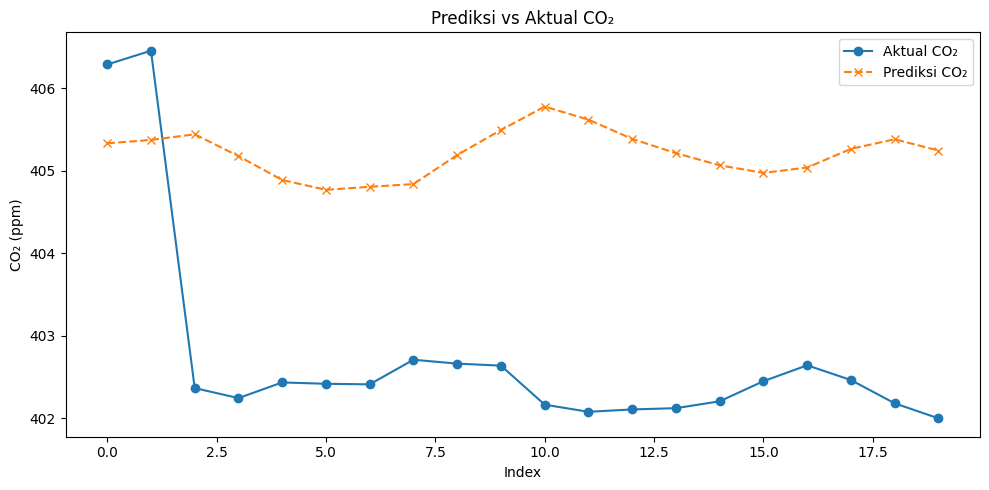

In [160]:
# Tambah fitur waktu
df_resampled['hour_sin'] = np.sin(2 * np.pi * df_resampled.index.hour / 24)
df_resampled['hour_cos'] = np.cos(2 * np.pi * df_resampled.index.hour / 24)
df_resampled['dow_sin'] = np.sin(2 * np.pi * df_resampled.index.dayofweek / 7)
df_resampled['dow_cos'] = np.cos(2 * np.pi * df_resampled.index.dayofweek / 7)

# Fitur input & target
X_df = df_resampled[['CO', 'hour_sin', 'hour_cos', 'dow_sin', 'dow_cos']]
y_df = df_resampled[['CO2']]

# Scaling
input_scaler = MinMaxScaler()
target_scaler = MinMaxScaler()
X_scaled = input_scaler.fit_transform(X_df)
y_scaled = target_scaler.fit_transform(y_df)

# Sequence windowing
sequence_length = 36
X_seq, y_seq = [], []
for i in range(len(X_scaled) - sequence_length):
    X_seq.append(X_scaled[i:i+sequence_length])
    y_seq.append(y_scaled[i+sequence_length])
X_seq, y_seq = np.array(X_seq), np.array(y_seq)

# Split data
n = len(X_seq)
train_end = int(0.7 * n)
val_end = int(0.9 * n)
X_train, y_train = X_seq[:train_end], y_seq[:train_end]
X_val, y_val = X_seq[train_end:val_end], y_seq[train_end:val_end]
X_test, y_test = X_seq[val_end:], y_seq[val_end:]

# Model LSTM sederhana
model = Sequential([
    Input(shape=(sequence_length, X_seq.shape[2])),
    LSTM(64),
    Dense(32, activation='relu'),
    Dense(1)
])
model.compile(optimizer='adam', loss='mse', metrics=['mae'])
model.summary()

# Training
model.fit(X_train, y_train, validation_data=(X_val, y_val), epochs=50, batch_size=32)

# Evaluasi
y_pred_scaled = model.predict(X_test)
y_pred = target_scaler.inverse_transform(y_pred_scaled)
y_true = target_scaler.inverse_transform(y_test)

# Visualisasi hasil
plt.figure(figsize=(10, 5))
plt.plot(y_true[:20], label='Aktual CO₂', marker='o')
plt.plot(y_pred[:20], label='Prediksi CO₂', linestyle='--', marker='x')
plt.title("Prediksi vs Aktual CO₂")
plt.xlabel("Index")
plt.ylabel("CO₂ (ppm)")
plt.legend()
plt.tight_layout()
plt.show()


In [183]:
# Ambil hanya CO2 dan CO
df = df_resampled[['CO2', 'CO']]

# Scaling per fitur
from sklearn.preprocessing import StandardScaler
scalers = {}
scaled_df = pd.DataFrame(index=df.index)
for col in df.columns:
    scaler = StandardScaler()
    scaled_df[col] = scaler.fit_transform(df[[col]])
    scalers[col] = scaler

data = scaled_df.to_numpy()
n = len(data)
train_size = int(n * 0.8)
val_size = int(n * 0.1)

# Dataset
def make_dataset(data, seq_len=36, ahead=1, batch_size=32, shuffle=True):
    ds = tf.keras.utils.timeseries_dataset_from_array(
        data, targets=None, sequence_length=seq_len+ahead,
        sequence_stride=1, shuffle=shuffle, batch_size=batch_size
    )
    return ds.map(lambda x: (x[:, :-ahead, :], x[:, -ahead:, :]))

ds_train = make_dataset(data[:train_size])
ds_val   = make_dataset(data[train_size:train_size+val_size])
ds_test  = make_dataset(data[train_size+val_size:], shuffle=False)


In [190]:
import tensorflow as tf
from tensorflow.keras import Model
from tensorflow.keras.layers import Input, LSTM, Dense, Attention, LayerNormalization, Add, GlobalAveragePooling1D
from tensorflow.keras.losses import Huber
from tensorflow.keras.optimizers import Adam

# === 1. Parameter ===
sequence_length = 36
n_features = 2  # ['CO2', 'CO']

# === 2. Arsitektur Model ===
input_layer = Input(shape=(sequence_length, n_features), name='Input_Sequence')

# LSTM Stack
x = LSTM(128, return_sequences=True, name='LSTM_1')(input_layer)
x = LSTM(64, return_sequences=True, name='LSTM_2')(x)

# Self-Attention Layer
query = Dense(64, name='Query')(x)
key = Dense(64, name='Key')(x)
value = Dense(64, name='Value')(x)

attn_output = Attention(name='Self_Attention')([query, key, value])
attn_output = Add(name='Add_Residual')([x, attn_output])
attn_output = LayerNormalization(name='LayerNorm')(attn_output)

# Pooling & Output
context = GlobalAveragePooling1D(name='GlobalAvgPool')(attn_output)
output = Dense(n_features, name='Output')(context)

# === 3. Compile Model ===
model = Model(inputs=input_layer, outputs=output, name='LSTM_with_Attention')
model.compile(optimizer=Adam(learning_rate=1e-3), loss=Huber(), metrics=['mae'])
model.summary()


Model: "LSTM_with_Attention"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 Input_Sequence (InputLayer)    [(None, 36, 2)]      0           []                               
                                                                                                  
 LSTM_1 (LSTM)                  (None, 36, 128)      67072       ['Input_Sequence[0][0]']         
                                                                                                  
 LSTM_2 (LSTM)                  (None, 36, 64)       49408       ['LSTM_1[0][0]']                 
                                                                                                  
 Query (Dense)                  (None, 36, 64)       4160        ['LSTM_2[0][0]']                 
                                                                                

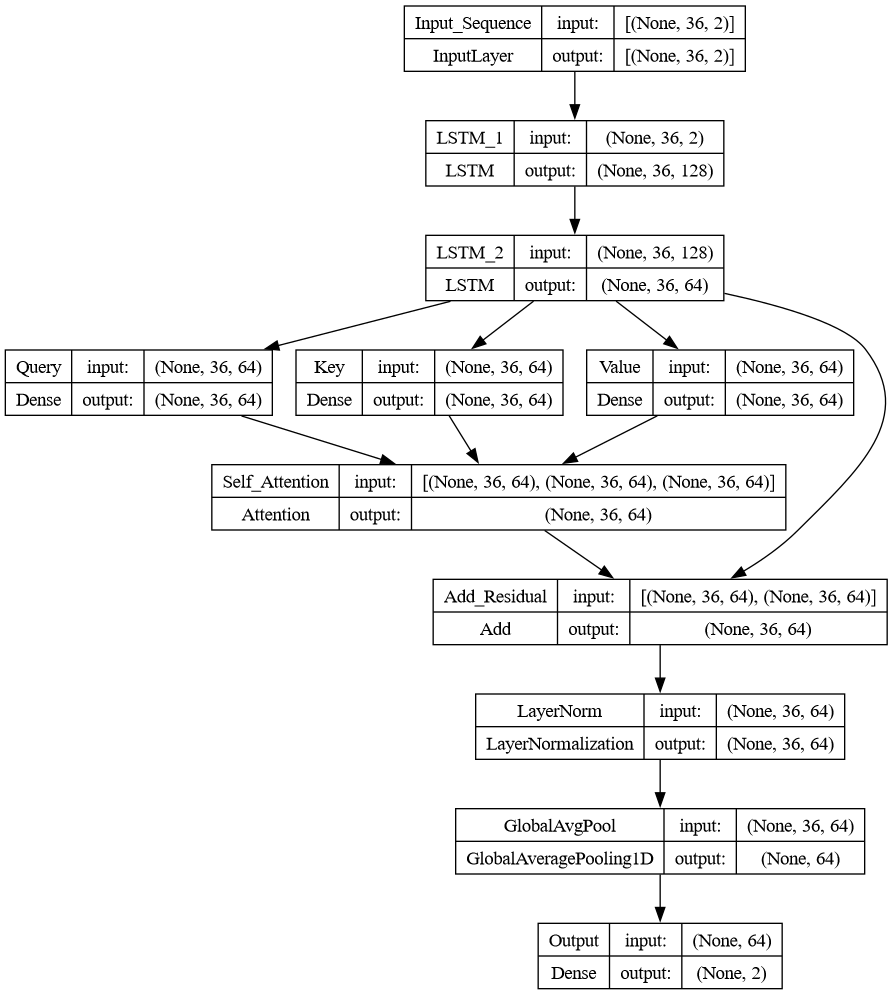

In [191]:
tf.keras.utils.plot_model(model, show_shapes=True)

In [192]:
history = model.fit(ds_train, validation_data=ds_val, epochs=100)
model.evaluate(ds_test)

Epoch 1/100


10/10 [==============================] - 3s 74ms/step - loss: 0.5737 - mae: 0.9568 - val_loss: 1.0478 - val_mae: 1.5280
Epoch 2/100
10/10 [==============================] - 0s 22ms/step - loss: 0.4009 - mae: 0.7731 - val_loss: 1.3548 - val_mae: 1.8523
Epoch 3/100
10/10 [==============================] - 0s 16ms/step - loss: 0.3787 - mae: 0.7435 - val_loss: 1.2219 - val_mae: 1.7184
Epoch 4/100
10/10 [==============================] - 0s 14ms/step - loss: 0.3709 - mae: 0.7386 - val_loss: 1.2738 - val_mae: 1.7705
Epoch 5/100
10/10 [==============================] - 0s 15ms/step - loss: 0.3676 - mae: 0.7341 - val_loss: 1.3956 - val_mae: 1.8944
Epoch 6/100
10/10 [==============================] - 0s 14ms/step - loss: 0.3679 - mae: 0.7308 - val_loss: 1.3293 - val_mae: 1.8271
Epoch 7/100
10/10 [==============================] - 0s 13ms/step - loss: 0.3658 - mae: 0.7299 - val_loss: 1.2566 - val_mae: 1.7522
Epoch 8/100
10/10 [==============================] - 0s 14ms/step - loss: 0.3696 - mae: 

[0.5528196096420288, 0.9699589014053345]

1/1 [==============================] - 0s 471ms/step


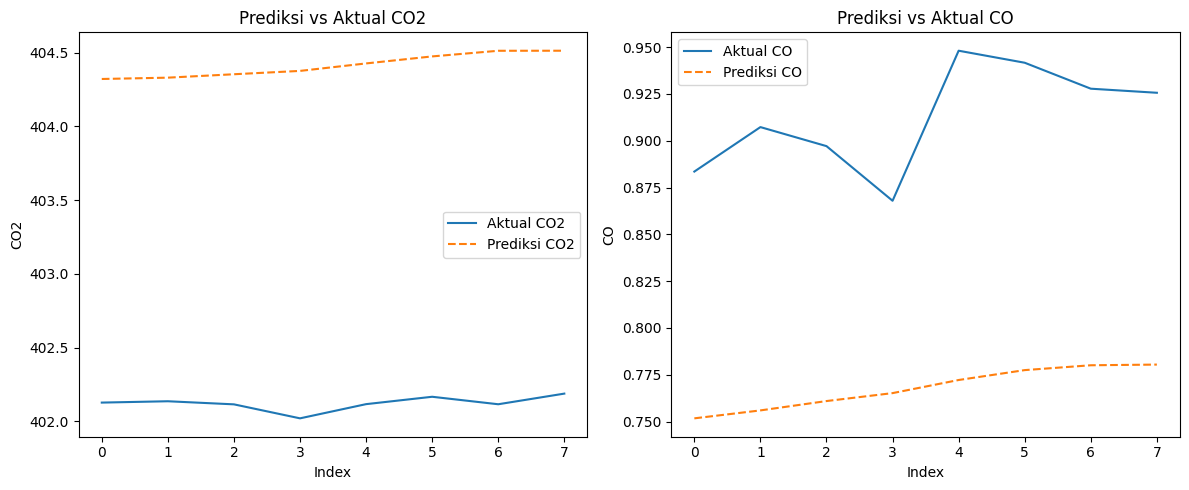

: 

In [ ]:
# Prediksi
y_pred_scaled = model.predict(ds_test)

# Ground truth
y_true_scaled = np.concatenate([y[:, 0, :] for _, y in ds_test], axis=0)

# Inverse transform
results = {}
for i, col in enumerate(['CO2', 'CO']):
    results[col] = {
        'pred': scalers[col].inverse_transform(y_pred_scaled[:, i].reshape(-1, 1)).flatten(),
        'true': scalers[col].inverse_transform(y_true_scaled[:, i].reshape(-1, 1)).flatten()
    }

# Plot
plt.figure(figsize=(12, 5))
for i, col in enumerate(['CO2', 'CO']):
    plt.subplot(1, 2, i+1)
    plt.plot(results[col]['true'][:20], label=f'Aktual {col}')
    plt.plot(results[col]['pred'][:20], label=f'Prediksi {col}', linestyle='--')
    plt.title(f'Prediksi vs Aktual {col}')
    plt.xlabel('Index')
    plt.ylabel(col)
    plt.legend()

plt.tight_layout()
plt.show()
